<a href="https://colab.research.google.com/github/news-trackers/nlp-workspace/blob/main/inference/Parallel_Inference_of_HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parallel Inference of HuggingFace 🤗 Transformers on CPUs**

An introduction to multiprocessing predictions of large machine learning and deep learning models

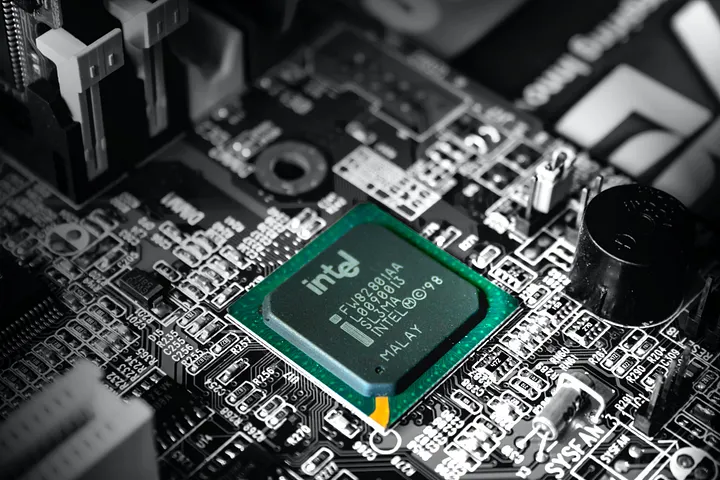

The current trend in AI research is moving towards the development of increasingly larger Deep Learning models, which constantly surpass each other in terms of performance. Recent examples in Natural Language Processing (NLP) are GPT-3, XLNet or the classical BERT transformer models. While the ever-improving results are inspiring researchers enthusiastically to research even larger models, this development also has a significant drawback. Training these large models is very expensive and time consuming. One of the reasons for this is that the Deep Learning models require training on a large number of GPUs at the same time. The resulting models are so big that they require GPUs not only for training, but also during inference time. Theoretically, inference on CPUs is possible. However, it takes a very long time for these large models to generate predictions on CPUs, which makes this approach not really feasible in practice. Unfortunately, the blockchain hype of recent years resulted in a GPU shortage which considerably limits GPU access for many people.



> What can we do if we want to benefit from the great performance of pre-trained Deep Learning models, without having GPU access? Do we necessarily have to turn to other approaches? The answer is no. At least for smaller projects, we may parallelize the model inference on CPUs to increase the prediction speed. However, in the long run and for larger projects, it is still highly recommended to get GPU access.



###**How to parallelize inference of Deep Learning models?**
In this tutorial, we will use Ray to perform parallel inference on pre-trained HuggingFace 🤗 Transformer models in Python. Ray is a framework for scaling computations not only on a single machine, but also on multiple machines. For this tutorial, we will use Ray on a single MacBook Pro (2019) with a 2,4 Ghz 8-Core Intel Core i9 processor.

**Why to use Ray for parallel inference?**
When dealing with parallel computing in Python, we usually make use of the multiprocessing module. However, this module has some limitations, which make it unsuitable for parallel inference of large models. Thereby, we need to consider mainly two factors in this context:



1.   The Python multiprocessing module uses pickle to serialize large objects when passing them between processes. This approach requires each process to create its own copy of the data, which adds substantial memory usage as well as overhead for expensive deserialization. In contrast, Ray uses shared memory to store objects, which can be accessed by all of the worker processes without having to deserialize or copy the values (Robert Nishihara). Considering that models usually try to predict a large amount of data, this factor alone can already speed up the computations when using Ray instead of the multiprocessing module.
2.   The Python multiprocessing module executes stateless functions, meaning that any variable produced in one map call that we want to use in another map call needs to be returned from the first call and passed into the second call. For small objects, this approach is acceptable, but when large intermediate results need to be shared, the cost of passing them around is prohibitive (Robert Nishihara). In our case, this means that we would need to reload our large HuggingFace 🤗 Transformer model on every map call, as the mapped functions are assumed to be stateless. Eventually, loading these models costs us so much time that we would likely end up being faster by loading the model only once and then have it predict the whole data on a single CPU instead of parallelizing the inference. In contrast, Ray provides an actor abstraction so that classes can be used in a parallel and distributed setting. With Ray, we can overcome this issue as we can avoid the model reloading cost by loading the model only once in the actor’s constructor and then using it for parallel inference on multiple CPUs.




If you want to know more about Ray, I recommend checking out Robert Nishiharas Blog.

**Tutorial**
In this tutorial, we will use Ray for parallelized predictions of text document classes from the 20 Newsgroups dataset on CPUs. The dataset is a collection of approximately 20,000 text documents, partitioned evenly across 20 different newsgroups categoties. In this tutorial, we will focus on a subset of the 20 Newsgroups dataset consisting of the categories “rec.motorcycles” and “rec.sport.baseball” only. We will use a DistilBERT entailment model to perform zero-shot text classification. Simply speaking, zero-shot classification works as follows:

We provide the zero-shot entailment model with candidate labels in text form which the model can then use to predict whether a given text is associated with the given candidate labels. The zero-shot entailment model does not have to be trained explicitly for the specific labels, but can perform the classification based on semantic meanings of unseen labels and texts.

###Zero-Shot Text Classification Example:

```
Text to classify:
The Avengers, is a 2012 American superhero film based on the Marvel Comics superhero team of the same name.
Candidate labels:
Movies, Automotive
When providing the zero-shot entailment model with both, the text and candidate labels, the model will then predict a relationship score between the text and labels:
Movies: 0.9856
Automotive: 0.0144
```
If you are interested, you can find a more detailed introduction to zero-shot text classification here. But now let’s get to the actual code example.

###Install the required Python packages:



In [ ]:
!pip install ray torch transformers scikit-learn psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 13.3 MB/s eta 0:00:00


###Loading the HuggingFace 🤗 Transformer model and data

First, we import all important packages, fetch the 20 Newsgroups dataset from Scikit-learn and init our zero-shot entailment model from HuggingFace 🤗.

In [ ]:

from sklearn.datasets import fetch_20newsgroups
from transformers import pipeline
import time
from datetime import timedelta
import psutil
import ray

# Load 20newsgroups news articles that that belong to “rec.motorcycles” and “rec.sport.baseball” classes of the test set only
test_data = fetch_20newsgroups(subset='test', shuffle=False, categories=['rec.motorcycles', 'rec.sport.baseball'], remove=('headers', 'footers', 'quotes'))
# Remove empty news article texts
test_data = [text for text in test_data.data if text!='']
print('Number of text articles:', len(test_data))

"""
HuggingFace pipelines are objects that abstract most of the complex code from the library,
offering a simple API dedicated to several tasks, including text classification.
All pipelines can use batching.
However, this is not automatically a win for performance.
It can be either a 10x speedup or 5x slowdown depending on hardware, data and the actual model being used.
Batching is only recommended on GPU.
If you are using CPU, don’t batch.
"""
# Init pipeline with batchsize 1 on CPU for our example
pipe = pipeline(task = 'zero-shot-classification', model='typeform/distilbert-base-uncased-mnli', batch_size=1, device=-1)


Number of text articles: 777


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]



```
Number of text articles: 777
```


###Predict a single text document and check the output

Let’s test the zero-shot model prediction on a single document.

In [ ]:
# Predict single text
prediction = pipe(test_data[100], ['motorcycle', 'baseball'])
print('Text:', prediction['sequence'])
print('Labels:', prediction['labels'])
print('Scores:', prediction['scores'])

Text: Hey, the Lone Biker of the Apocalypse (see Raising Arizona) had flames coming
out of both his exhaust pipes. I love to toggle the kill switch on my Sportster
to produce flaming backfires, especially underneath overpasses at night (it's
loud and lights up the whole underpass!!!
Labels: ['motorcycle', 'baseball']
Scores: [0.9970589876174927, 0.0029409590642899275]




```
Text: Hey, the Lone Biker of the Apocalypse (see Raising Arizona) had flames coming
out of both his exhaust pipes. I love to toggle the kill switch on my Sportster
to produce flaming backfires, especially underneath overpasses at night (it's
loud and lights up the whole underpass!!!
Labels: ['motorcycle', 'baseball']
Scores: [0.9970590472221375, 0.002940954640507698]
```


We can observe that our zero-shot entailment model can correctly predict the class without being trained on the dataset beforehand.

###Predict all text documents on a single CPU

Let’s predict the classes of all text documents on a single CPU and measure the computation time.

In [ ]:
# Predict multipe texts on single CPU and time the inference duration
start = time.time()

predictions = [pipe(text, ['motorcycle', 'baseball']) for text in test_data]

end = time.time()
print('Prediction time:', str(timedelta(seconds=end-start)))

Prediction time: 0:05:02.849072




```
Prediction time: 0:04:12.172323
```

###Predict all text documents on multiple CPUs

Let’s predict the classes of all text documents on multiple CPUs and measure the computation time.

In [ ]:
num_cpus = psutil.cpu_count(logical=True)
print('Number of available CPUs:', num_cpus)

# Start Ray cluster
ray.init(num_cpus=num_cpus, ignore_reinit_error=True)

"""
The command ray.put(x) would be run by a worker process or by the driver process (the driver process is the one running your script).
It takes a Python object and copies it to the local object store (here local means on the same node).
Once the object has been stored in the object store, its value cannot be changed.
In addition, ray.put(x) returns an object ID, which is essentially an ID that can be used to refer to the newly created remote object.
If we save the object ID in a variable with x_id = ray.put(x),
then we can pass x_id into remote functions,
and those remote functions will operate on the corresponding remote object.
"""
pipe_id = ray.put(pipe)

# @ray.remote decorator enables to use this
# function in distributed setting
@ray.remote
def predict(pipeline, text_data, label_names):
    return pipeline(text_data, label_names)

# Predict multipe texts on all available CPUs and time the inference duration
start = time.time()

# Run the function using multiple cores and gather the results
predictions = ray.get([predict.remote(pipe_id, text, ['motorcycle', 'baseball']) for text in test_data])

end = time.time()
print('Prediction time:', str(timedelta(seconds=end-start)))

# Stop running Ray cluster
ray.shutdown()

Number of available CPUs: 2


2026-08-16 16:52:26,396	INFO worker.py:2024 -- Started a local Ray instance.


Prediction time: 0:06:20.596785




```
Number of available CPUs: 16
Prediction time: 0:01:58.203863
```



Compared to the calculation on only one CPU, we have significantly reduced the prediction time by leveraging multiple CPUs. To parallelize the prediction with Ray, we only need to put the HuggingFace 🤗 pipeline (including the transformer model) in the local object store, define a prediction function predict(), and decorate it with @ray.remote. Afterwards, we have to execute the function in a remote setting and gather the results with ray.get().

###**Summary**
Ray is an easy to use framework for scaling computations. We can use it to perform parallel CPU inference on pre-trained HuggingFace 🤗 Transformer models and other large Machine Learning/Deep Learning models in Python. If you want to know more about Ray and its possibilities, please check out the Ray docs.